In [2]:
# ==========================================================
# TCGA Breast Cancer Biomarker Discovery
# Author: Pal Rabheru
# Project 4 - Bioinformatics Portfolio
# ==========================================================

# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

# Better looking plots
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
expression = pd.read_csv(
    "../data/raw/TCGA-BRCA.star_fpkm.tsv.gz",
    sep="\t",
    compression="gzip"
)

In [4]:
expression.head()


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,3.061880,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800
1,ENSG00000000005.6,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.037453,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212
2,ENSG00000000419.13,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.533395,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261
3,ENSG00000000457.14,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.238512,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108
4,ENSG00000000460.17,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.210015,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719


In [5]:
expression.shape

(60660, 1227)

In [6]:
expression.info()


<class 'pandas.DataFrame'>
RangeIndex: 60660 entries, 0 to 60659
Columns: 1227 entries, Ensembl_ID to TCGA-A1-A0SN-01A
dtypes: float64(1226), str(1)
memory usage: 567.9 MB


In [7]:
expression_original = expression.copy()

In [8]:
expression["Ensembl_ID"] = (
    expression["Ensembl_ID"]
    .str.split(".")
    .str[0]
)

In [9]:
expression.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,3.061880,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800
1,ENSG00000000005,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.037453,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212
2,ENSG00000000419,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.533395,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261
3,ENSG00000000457,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.238512,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108
4,ENSG00000000460,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.210015,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719


In [10]:
expression.isnull().sum().sum()

np.int64(0)

In [11]:
expression["Ensembl_ID"].duplicated().sum()

np.int64(44)

In [12]:
duplicates = expression[
    expression["Ensembl_ID"].duplicated(keep=False)
]

duplicates.head(20)

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
23,ENSG00000002586,5.750030,5.535789,4.503978,4.986789,3.334740,6.461786,5.721693,5.014721,4.687212,...,5.887506,5.872238,5.616243,4.548788,4.093231,5.620959,5.579835,3.990265,4.830098,5.439630
24,ENSG00000002586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5507,ENSG00000124333,4.454426,4.660415,4.740944,4.577755,5.030438,4.627893,4.625569,5.101415,4.397324,...,4.515958,4.105670,5.784247,5.323035,4.277300,4.630662,4.145188,4.002306,4.693336,4.920217
5508,ENSG00000124333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5509,ENSG00000124334,0.058940,0.063089,0.107956,0.413377,0.023894,0.011209,0.130272,0.039138,0.126973,...,0.118094,0.307429,0.229711,0.083656,0.308128,0.030689,0.240375,0.027862,0.244035,0.510152
5510,ENSG00000124334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12082,ENSG00000167393,1.249870,0.693052,1.191436,0.970927,1.217107,3.064917,1.307079,0.763242,0.971810,...,1.315624,1.188338,1.267236,0.575796,1.502280,1.097948,1.109962,1.519592,1.292546,1.120485
12083,ENSG00000167393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12508,ENSG00000169084,3.200834,3.120369,3.386852,3.211168,2.740712,3.652314,3.223994,2.822710,1.836005,...,3.270529,3.711275,3.154178,2.520774,3.293679,2.319242,2.428839,3.040927,3.086546,3.200457
12509,ENSG00000169084,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
expression = expression.drop_duplicates(
    subset="Ensembl_ID",
    keep="first"
)

In [14]:
expression["Ensembl_ID"].duplicated().sum()

np.int64(0)

In [15]:
expression.shape

(60616, 1227)

# Gene Annotation

Convert Ensembl gene identifiers into standard human gene symbols using Ensembl BioMart.

**Objective**

- Improve interpretability of the dataset.
- Enable biological interpretation.
- Prepare the dataset for downstream biomarker discovery.

In [16]:
from pybiomart import Dataset

In [17]:
dataset = Dataset(
    name="hsapiens_gene_ensembl",
    host="http://www.ensembl.org"
)

In [18]:
annotation = dataset.query(
    attributes=[
        "ensembl_gene_id",
        "external_gene_name"
    ]
)

In [19]:
annotation.head()

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [20]:
annotation.columns = ["Ensembl_ID", "Gene_Symbol"]

annotation.head()

,Ensembl_ID,Gene_Symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [21]:
expression = expression.merge(
    annotation,
    on="Ensembl_ID",
    how="left"
)

In [22]:
expression.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
0,ENSG00000000003,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800,TSPAN6
1,ENSG00000000005,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212,TNMD
2,ENSG00000000419,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261,DPM1
3,ENSG00000000457,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108,SCYL3
4,ENSG00000000460,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719,FIRRM


In [23]:
expression["Gene_Symbol"].notna().sum()

np.int64(42878)

In [24]:
expression = expression.dropna(subset=["Gene_Symbol"])

expression.shape

(42878, 1228)

In [26]:
expression.to_csv(
    "../data/processed/TCGA_BRCA_expression_annotated.csv",
    index=False
)

print("Annotated expression dataset saved successfully!")

Annotated expression dataset saved successfully!


## Clinical Data Processing

### Objective

Load and explore the TCGA BRCA clinical dataset to identify patient characteristics and prepare the data for integration with gene expression profiles.

In [29]:
clinical = pd.read_csv(
    "../data/metadata/TCGA-BRCA.clinical.tsv.gz",
    sep="\t",
    compression="gzip"
)

In [30]:
clinical.shape

(1255, 85)

In [31]:
clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 85 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     1255 non-null   str    
 1   id                                                         1255 non-null   str    
 2   disease_type                                               1255 non-null   str    
 3   case_id                                                    1255 non-null   str    
 4   submitter_id                                               1255 non-null   str    
 5   primary_site                                               1255 non-null   str    
 6   alcohol_history.exposures                                  1254 non-null   str    
 7   race.demographic                                           1254 non-null   str    
 8   gender.demographic 

In [33]:
clinical.columns.tolist()

['sample',
 'id',
 'disease_type',
 'case_id',
 'submitter_id',
 'primary_site',
 'alcohol_history.exposures',
 'race.demographic',
 'gender.demographic',
 'ethnicity.demographic',
 'vital_status.demographic',
 'age_at_index.demographic',
 'days_to_birth.demographic',
 'year_of_birth.demographic',
 'year_of_death.demographic',
 'primary_site.project',
 'project_id.project',
 'disease_type.project',
 'name.project',
 'name.program.project',
 'tissue_source_site_id.tissue_source_site',
 'code.tissue_source_site',
 'name.tissue_source_site',
 'project.tissue_source_site',
 'bcr_id.tissue_source_site',
 'days_to_death.demographic',
 'entity_submitter_id.annotations',
 'notes.annotations',
 'submitter_id.annotations',
 'classification.annotations',
 'entity_id.annotations',
 'created_datetime.annotations',
 'annotation_id.annotations',
 'entity_type.annotations',
 'updated_datetime.annotations',
 'case_id.annotations',
 'state.annotations',
 'category.annotations',
 'status.annotations',
 '

In [34]:
clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].head()

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-BH-A0W3,Alive,58.0,female,white
1,TCGA-AR-A24V,Alive,52.0,female,white
2,TCGA-E9-A1NE,Alive,28.0,female,white
3,TCGA-E9-A1NE,Alive,28.0,female,white
4,TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [35]:
clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].isnull().sum()

submitter_id                0
vital_status.demographic    1
age_at_index.demographic    1
gender.demographic          1
race.demographic            1
dtype: int64

In [36]:
clinical_clean = clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].dropna()

In [37]:
clinical_clean.shape

(1254, 5)

In [38]:
clinical_clean.head()

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-BH-A0W3,Alive,58.0,female,white
1,TCGA-AR-A24V,Alive,52.0,female,white
2,TCGA-E9-A1NE,Alive,28.0,female,white
3,TCGA-E9-A1NE,Alive,28.0,female,white
4,TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [39]:
sample_columns = expression.columns[1:-1]

patient_ids = [sample[:12] for sample in sample_columns]

print(patient_ids[:5])

['TCGA-D8-A146', 'TCGA-AQ-A0Y5', 'TCGA-C8-A274', 'TCGA-BH-A0BD', 'TCGA-B6-A1KC']


In [40]:
common_patients = set(patient_ids).intersection(
    set(clinical_clean["submitter_id"])
)

print(f"Common patients: {len(common_patients)}")

Common patients: 1094


In [41]:
clinical_clean.to_csv(
    "../data/processed/TCGA_BRCA_clinical_clean.csv",
    index=False
)

print("Clinical dataset saved successfully!")

Clinical dataset saved successfully!


In [42]:
clinical_lookup = clinical_clean.set_index("submitter_id")

clinical_lookup.head()

,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
submitter_id,,,,
TCGA-BH-A0W3,Alive,58.0,female,white
TCGA-AR-A24V,Alive,52.0,female,white
TCGA-E9-A1NE,Alive,28.0,female,white
TCGA-E9-A1NE,Alive,28.0,female,white
TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [43]:
clinical_lookup.loc["TCGA-BH-A0W3"]

vital_status.demographic     Alive
age_at_index.demographic      58.0
gender.demographic          female
race.demographic             white
Name: TCGA-BH-A0W3, dtype: object

In [44]:
"TCGA-BH-A0W3" in clinical_lookup.index

True

In [46]:
clinical_clean["submitter_id"].duplicated().sum()

np.int64(157)

In [47]:
clinical_clean[
    clinical_clean["submitter_id"].duplicated(keep=False)
].sort_values("submitter_id")

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
315,TCGA-A7-A0CE,Alive,57.0,female,white
314,TCGA-A7-A0CE,Alive,57.0,female,white
318,TCGA-A7-A0CH,Alive,79.0,female,white
317,TCGA-A7-A0CH,Alive,79.0,female,white
1254,TCGA-A7-A0D9,Alive,37.0,female,white
...,...,...,...,...,...
699,TCGA-GI-A2C8,Alive,63.0,female,white
940,TCGA-GI-A2C9,Alive,58.0,female,black or african american
941,TCGA-GI-A2C9,Alive,58.0,female,black or african american
557,TCGA-XX-A899,Alive,46.0,female,white


In [48]:
clinical_clean = clinical_clean.drop_duplicates(subset="submitter_id")

In [49]:
clinical_clean["submitter_id"].duplicated().sum()

np.int64(0)

In [50]:
clinical_lookup = clinical_clean.set_index("submitter_id")

In [51]:
matched_clinical = clinical_lookup.reindex(patient_ids)

In [52]:
matched_clinical.shape

(1226, 4)

In [53]:
matched_clinical.notna().all(axis=1).sum()

np.int64(1225)

# Exploratory Data Analysis (EDA)

## Objective

Now that the gene expression and clinical datasets have been cleaned and integrated, we will explore the data through summary statistics and visualizations. This helps us understand patient characteristics, identify patterns, detect potential outliers, and generate hypotheses before performing biomarker discovery and statistical analyses.

## 1. Patient Demographics

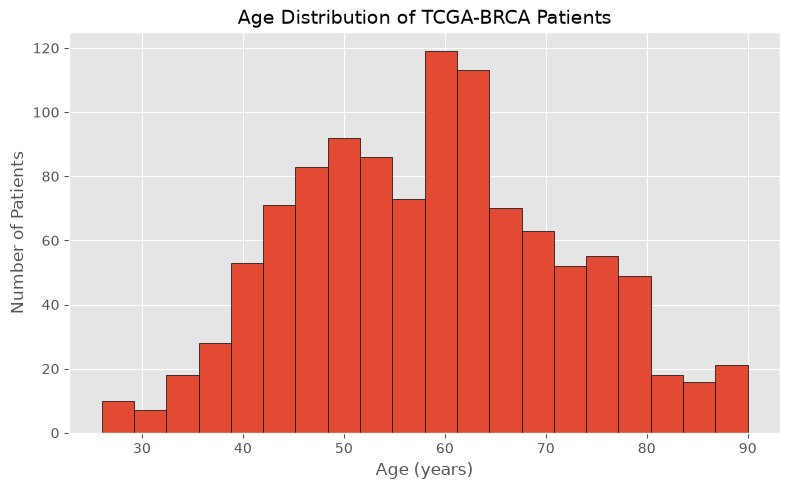

In [58]:
plt.figure(figsize=(8,5))

plt.hist(
    clinical_clean["age_at_index.demographic"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution of TCGA-BRCA Patients", fontsize=14)
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

## 2. Vital Status Distribution

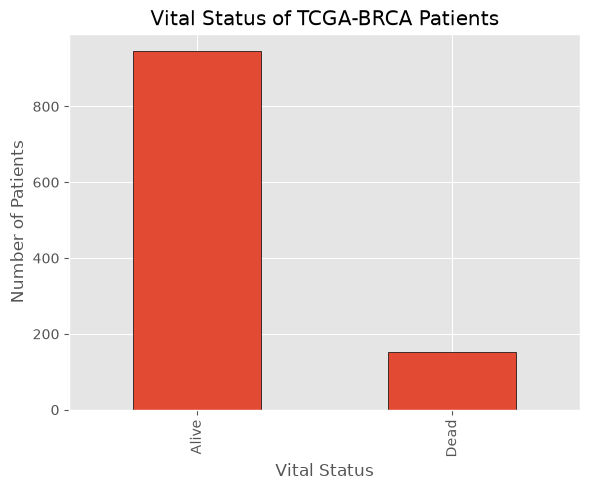

In [59]:
plt.figure(figsize=(6,5))

clinical_clean["vital_status.demographic"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Vital Status of TCGA-BRCA Patients")
plt.xlabel("Vital Status")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/vital_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Gender Distribution

Visualize the distribution of patient gender within the TCGA-BRCA cohort.

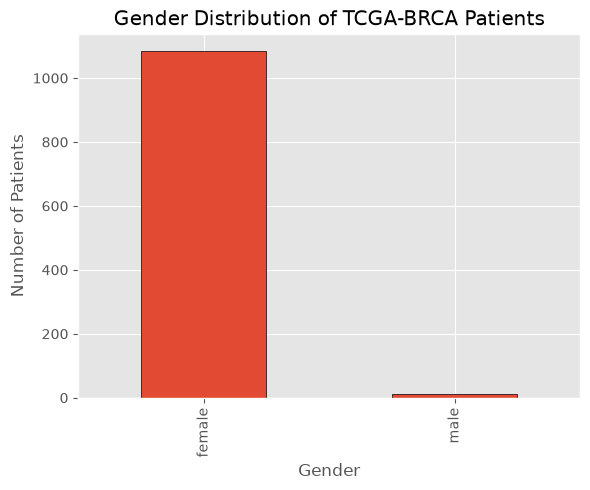

In [60]:
plt.figure(figsize=(6,5))

clinical_clean["gender.demographic"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Gender Distribution of TCGA-BRCA Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Expression of TP53

TP53 is a well-known tumor suppressor gene involved in regulating cell growth and preventing the accumulation of DNA damage. Here, we examine its expression across the TCGA-BRCA cohort.

In [67]:
expression[expression["Gene_Symbol"] == "TP53"]

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
8121,ENSG00000141510,3.655386,3.304263,4.243738,4.410416,3.838962,3.350724,3.95939,3.405107,4.156995,...,3.641396,3.806891,3.86844,4.536569,3.187562,2.991916,3.438532,4.864444,4.22064,TP53


In [68]:
tp53 = expression[expression["Gene_Symbol"] == "TP53"]

tp53

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
8121,ENSG00000141510,3.655386,3.304263,4.243738,4.410416,3.838962,3.350724,3.95939,3.405107,4.156995,...,3.641396,3.806891,3.86844,4.536569,3.187562,2.991916,3.438532,4.864444,4.22064,TP53


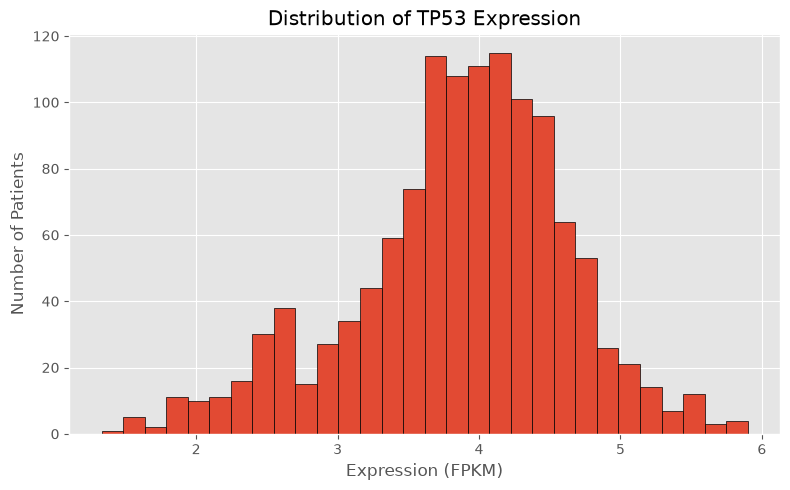

In [69]:
# Extract TP53 expression values
tp53_values = tp53.iloc[0, 1:-1]

# Convert to numeric values
tp53_values = pd.to_numeric(tp53_values)

# Create histogram
plt.figure(figsize=(8,5))

plt.hist(tp53_values, bins=30, edgecolor="black")

plt.title("Distribution of TP53 Expression")
plt.xlabel("Expression (FPKM)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/tp53_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
tp53_df = pd.DataFrame({
    "submitter_id": patient_ids,
    "TP53_expression": tp53_values.values
})

tp53_df.head()

,submitter_id,TP53_expression
0,TCGA-D8-A146,3.655386
1,TCGA-AQ-A0Y5,3.304263
2,TCGA-C8-A274,4.243738
3,TCGA-BH-A0BD,4.410416
4,TCGA-B6-A1KC,3.838962


In [72]:
tp53_clinical = tp53_df.merge(
    clinical_clean,
    on="submitter_id",
    how="inner"
)

tp53_clinical.head()

,submitter_id,TP53_expression,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-D8-A146,3.655386,Alive,57.0,female,white
1,TCGA-AQ-A0Y5,3.304263,Dead,70.0,female,white
2,TCGA-C8-A274,4.243738,Alive,63.0,female,asian
3,TCGA-BH-A0BD,4.410416,Alive,47.0,female,white
4,TCGA-B6-A1KC,3.838962,Alive,67.0,female,white


In [73]:
tp53_clinical.shape

(1225, 6)

## 6. TP53 Expression by Vital Status

Compare TP53 expression between patients who were alive and deceased at the time of data collection.

<Figure size 700x500 with 0 Axes>

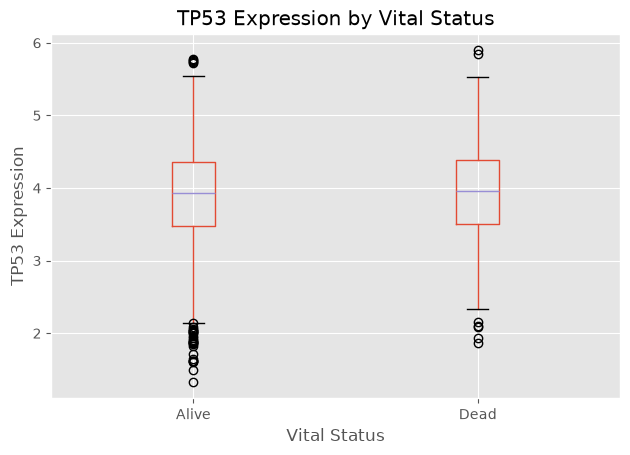

In [74]:
plt.figure(figsize=(7,5))

tp53_clinical.boxplot(
    column="TP53_expression",
    by="vital_status.demographic"
)

plt.title("TP53 Expression by Vital Status")
plt.suptitle("")  # Removes the default pandas title
plt.xlabel("Vital Status")
plt.ylabel("TP53 Expression")

plt.tight_layout()

plt.savefig(
    "../results/figures/tp53_by_vital_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Expression of BRCA1

BRCA1 is a tumor suppressor gene involved in DNA repair. Alterations in BRCA1 are associated with hereditary breast and ovarian cancer. Here, we examine BRCA1 expression across TCGA-BRCA patients.

In [75]:
brca1 = expression[expression["Gene_Symbol"] == "BRCA1"]

brca1

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
309,ENSG00000012048,1.026375,1.043624,1.94182,2.254927,2.311736,1.396598,0.898711,2.214249,1.535207,...,1.100305,2.176131,1.503145,2.060047,1.740884,1.369885,2.769539,1.874246,1.839798,BRCA1


In [77]:
brca1_values = brca1.iloc[0, 1:-1]

brca1_values = pd.to_numeric(brca1_values)

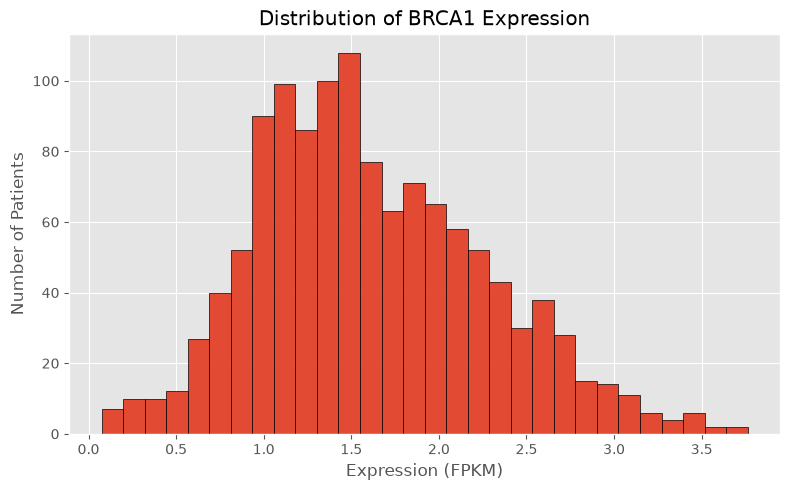

In [78]:
plt.figure(figsize=(8,5))

plt.hist(
    brca1_values,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of BRCA1 Expression")
plt.xlabel("Expression (FPKM)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/brca1_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 700x500 with 0 Axes>

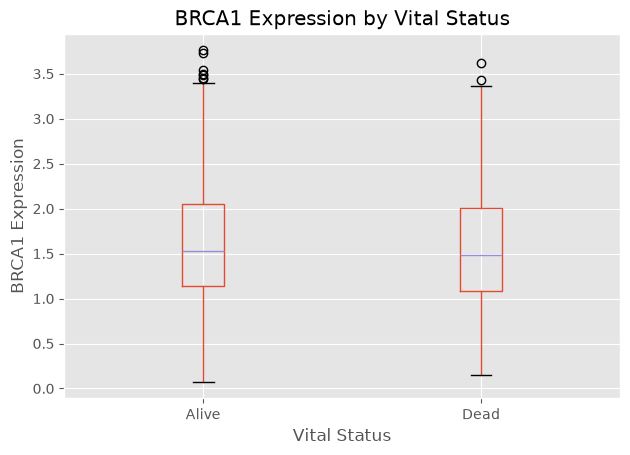

In [79]:
brca1_df = pd.DataFrame({
    "submitter_id": patient_ids,
    "BRCA1_expression": brca1_values.values
})

brca1_clinical = brca1_df.merge(
    clinical_clean,
    on="submitter_id",
    how="inner"
)

plt.figure(figsize=(7,5))

brca1_clinical.boxplot(
    column="BRCA1_expression",
    by="vital_status.demographic"
)

plt.title("BRCA1 Expression by Vital Status")
plt.suptitle("")
plt.xlabel("Vital Status")
plt.ylabel("BRCA1 Expression")

plt.tight_layout()

plt.savefig(
    "../results/figures/brca1_by_vital_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

BRCA1 expression showed a similar distribution between patients who were alive and those who were deceased. The median expression and variability were comparable in both groups, and considerable overlap was observed. Although a few high-expression outliers were present, visual inspection alone does not suggest a strong association between BRCA1 expression and patient survival. Statistical testing will be performed later to evaluate this formally.

## 8. Reusable Functions for Gene Expression Analysis

To avoid repetitive code, reusable functions are created to visualize the expression of any gene across the TCGA-BRCA cohort and compare its expression between patient groups.

In [80]:
def plot_gene_distribution(gene_symbol):
    """
    Plot the distribution of expression values for a given gene.
    """

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    if gene.empty:
        print(f"{gene_symbol} not found.")
        return

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    plt.figure(figsize=(8,5))

    plt.hist(
        values,
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {gene_symbol} Expression")
    plt.xlabel("Expression (FPKM)")
    plt.ylabel("Number of Patients")

    plt.tight_layout()
    plt.show()

In [81]:
def plot_gene_by_vital_status(gene_symbol):
    """
    Compare gene expression between Alive and Dead patients.
    """

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    if gene.empty:
        print(f"{gene_symbol} not found.")
        return

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    plt.figure(figsize=(7,5))

    merged.boxplot(
        column="Expression",
        by="vital_status.demographic"
    )

    plt.title(f"{gene_symbol} Expression by Vital Status")
    plt.suptitle("")
    plt.xlabel("Vital Status")
    plt.ylabel("Expression (FPKM)")

    plt.tight_layout()
    plt.show()

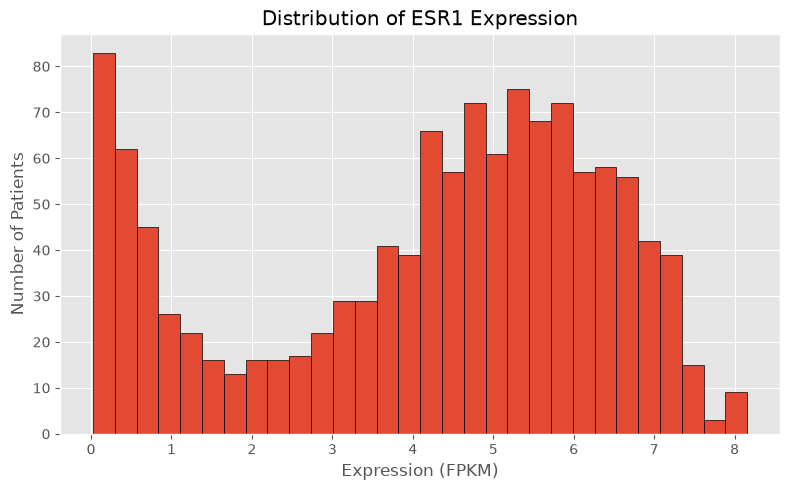

<Figure size 700x500 with 0 Axes>

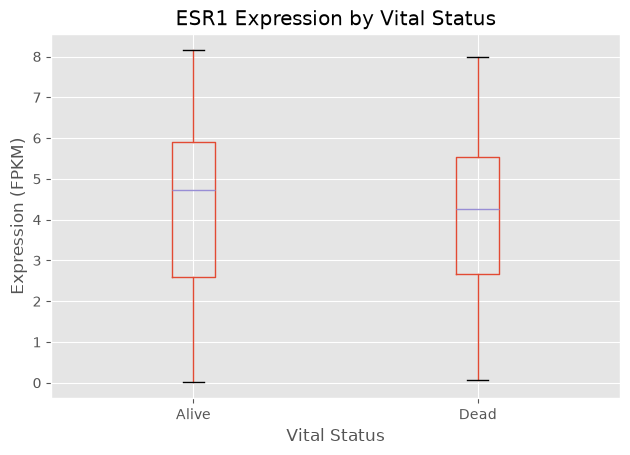

In [82]:
plot_gene_distribution("ESR1")
plot_gene_by_vital_status("ESR1")

## 8.1 ESR1 Expression Analysis

ESR1 encodes the estrogen receptor alpha, a key biomarker in breast cancer. High ESR1 expression is commonly associated with estrogen receptor-positive tumors and guides the use of endocrine therapies.

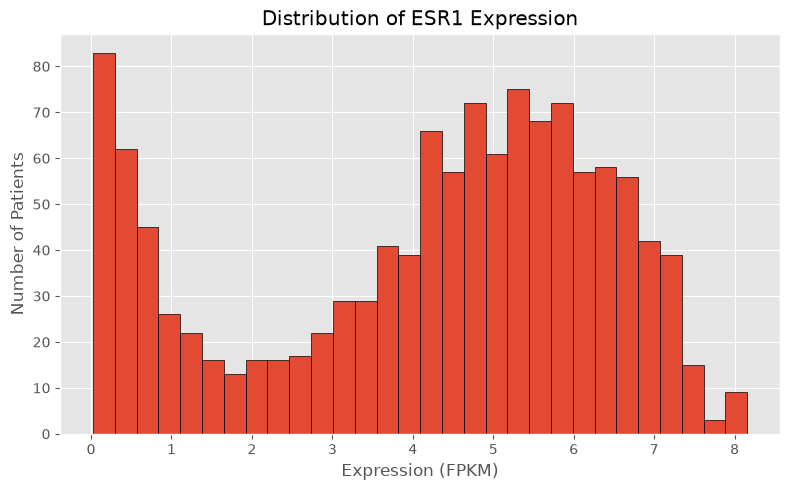

<Figure size 700x500 with 0 Axes>

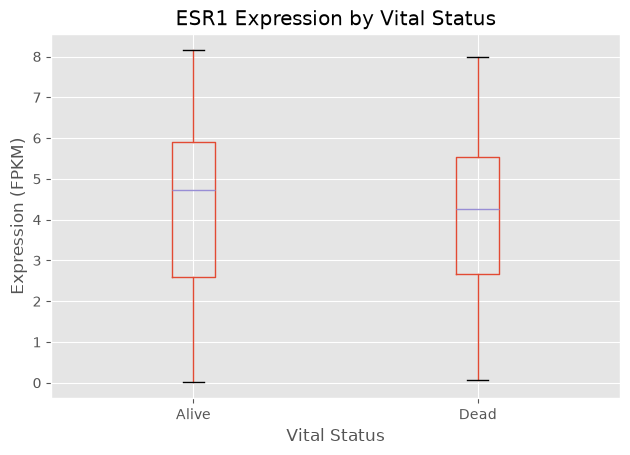

In [86]:
plot_gene_distribution("ESR1")
plot_gene_by_vital_status("ESR1")

## 8.2 ERBB2 (HER2) Expression Analysis

ERBB2 (HER2) is an oncogene that is overexpressed in a subset of breast cancers. HER2 status is routinely used to guide targeted therapy and is an important clinical biomarker.

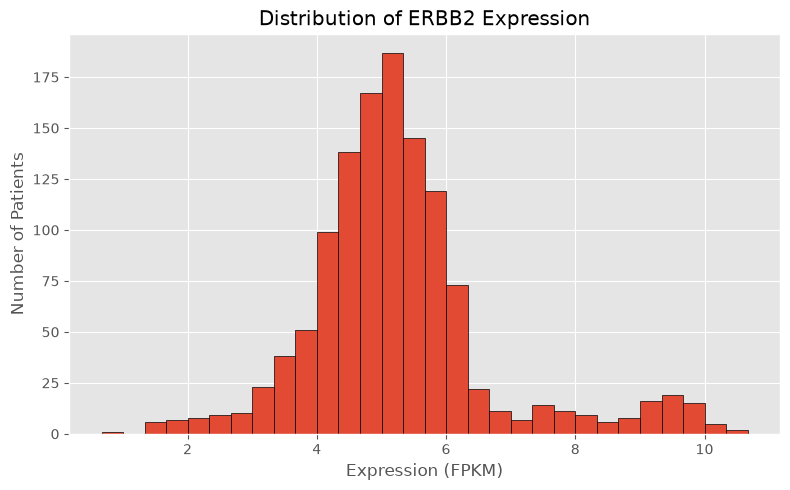

<Figure size 700x500 with 0 Axes>

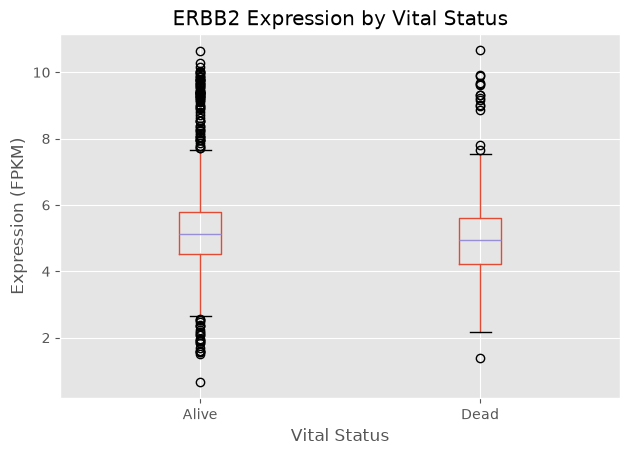

In [87]:
plot_gene_distribution("ERBB2")
plot_gene_by_vital_status("ERBB2")

# 9. Statistical Analysis

Visual differences between groups do not necessarily indicate statistically significant differences. Therefore, the Mann–Whitney U test was used to compare gene expression between patients who were alive and deceased.

In [88]:
from scipy.stats import mannwhitneyu

In [89]:
def mann_whitney_test(gene_symbol):

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    alive = merged[
        merged["vital_status.demographic"] == "Alive"
    ]["Expression"]

    dead = merged[
        merged["vital_status.demographic"] == "Dead"
    ]["Expression"]

    statistic, p = mannwhitneyu(
        alive,
        dead,
        alternative="two-sided"
    )

    print(f"\nGene: {gene_symbol}")
    print(f"U statistic: {statistic:.2f}")
    print(f"P-value: {p:.5f}")

    if p < 0.05:
        print("Result: Statistically significant difference.")
    else:
        print("Result: No statistically significant difference.")

In [90]:
mann_whitney_test("TP53")
mann_whitney_test("BRCA1")
mann_whitney_test("ESR1")
mann_whitney_test("ERBB2")


Gene: TP53
U statistic: 99792.00
P-value: 0.55411
Result: No statistically significant difference.

Gene: BRCA1
U statistic: 106368.50
P-value: 0.39800
Result: No statistically significant difference.

Gene: ESR1
U statistic: 110245.00
P-value: 0.09060
Result: No statistically significant difference.

Gene: ERBB2
U statistic: 113970.00
P-value: 0.01220
Result: Statistically significant difference.


## Statistical Summary

The Mann–Whitney U test was used to compare gene expression between patients who were alive and deceased.

| Gene | P-value | Interpretation |
|------|---------:|---------------|
| TP53 | 0.554 | No significant difference |
| BRCA1 | 0.398 | No significant difference |
| ESR1 | 0.091 | No significant difference |
| ERBB2 | 0.012 | Significant difference |

Among the four genes examined, only **ERBB2** showed a statistically significant difference in expression between the two patient groups (p < 0.05). TP53, BRCA1, and ESR1 did not show statistically significant differences in this comparison.

## 10.1 Genome-wide Mann–Whitney U Testing

Each annotated gene was compared between patients who were alive and deceased using the Mann–Whitney U test. The resulting p-values were collected for all genes to identify potential survival-associated biomarkers.

In [93]:
results = []

for i in range(len(expression)):

    gene_symbol = expression.iloc[i]["Gene_Symbol"]

    values = pd.to_numeric(expression.iloc[i, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    alive = merged[
        merged["vital_status.demographic"] == "Alive"
    ]["Expression"]

    dead = merged[
        merged["vital_status.demographic"] == "Dead"
    ]["Expression"]

    statistic, p = mannwhitneyu(
        alive,
        dead,
        alternative="two-sided"
    )

    results.append([
        gene_symbol,
        statistic,
        p
    ])

In [94]:
len(results)

42878

In [95]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Gene_Symbol",
        "U_statistic",
        "P_value"
    ]
)

results_df.head()

,Gene_Symbol,U_statistic,P_value
0,TSPAN6,92628.0,0.031005
1,TNMD,91102.0,0.012740
2,DPM1,102100.0,0.930438
3,SCYL3,107942.5,0.234391
4,FIRRM,109945.0,0.103804


In [97]:
from statsmodels.stats.multitest import multipletests

In [98]:
results_df["FDR"] = multipletests(
    results_df["P_value"],
    method="fdr_bh"
)[1]

results_df.head()

,Gene_Symbol,U_statistic,P_value,FDR
0,TSPAN6,92628.0,0.031005,NaN
1,TNMD,91102.0,0.012740,NaN
2,DPM1,102100.0,0.930438,NaN
3,SCYL3,107942.5,0.234391,NaN
4,FIRRM,109945.0,0.103804,NaN


In [99]:
results_df = results_df.sort_values(
    "FDR"
)

results_df.head(20)

,Gene_Symbol,U_statistic,P_value,FDR
0,TSPAN6,92628.0,0.031005,NaN
1,TNMD,91102.0,0.012740,NaN
2,DPM1,102100.0,0.930438,NaN
3,SCYL3,107942.5,0.234391,NaN
4,FIRRM,109945.0,0.103804,NaN
5,FGR,103782.5,0.779379,NaN
6,CFH,90039.0,0.006475,NaN
7,FUCA2,100099.5,0.599986,NaN
8,GCLC,90474.5,0.008600,NaN
9,NFYA,103302.0,0.860974,NaN


In [101]:
results_df["P_value"].isna().sum()
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42878 entries, 0 to 42877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gene_Symbol  42878 non-null  str    
 1   U_statistic  42878 non-null  float64
 2   P_value      41513 non-null  float64
 3   FDR          0 non-null      float64
dtypes: float64(3), str(1)
memory usage: 1.3 MB


In [102]:
results_df["P_value"].describe()
results_df[results_df["P_value"].isna()].head()

,Gene_Symbol,U_statistic,P_value,FDR
277,NME1-NME2,102500.0,NaN,NaN
2584,MCTS2,102500.0,NaN,NaN
2811,CORO7-PAM16,102500.0,NaN,NaN
3083,ICAM4,102500.0,NaN,NaN
5469,PEDS1-UBE2V1,102500.0,NaN,NaN


In [103]:
results_df = results_df.dropna(subset=["P_value"]).copy()

print(results_df.shape)

(41513, 4)


In [104]:
results_df["FDR"] = multipletests(
    results_df["P_value"],
    method="fdr_bh"
)[1]

In [105]:
results_df = results_df.sort_values("FDR")

results_df.head(20)

,Gene_Symbol,U_statistic,P_value,FDR
39855,LINC01235,73517.5,2.407276e-10,0.000010
434,DEF6,129611.5,3.142309e-09,0.000036
9806,KLF10,75169.0,2.344369e-09,0.000036
5814,SBDS,75468.0,3.492102e-09,0.000036
13434,ZBTB21,76189.0,8.973588e-09,0.000044
4442,CHMP3,76093.0,7.924972e-09,0.000044
3503,UBTF,129054.0,6.546328e-09,0.000044
19924,LINC00583,89530.0,9.555450e-09,0.000044
10148,PRXL2C,76044.0,7.436683e-09,0.000044
13431,MZT2A,128458.0,1.411927e-08,0.000055


In [106]:
results_df.info()

<class 'pandas.DataFrame'>
Index: 41513 entries, 39855 to 29003
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gene_Symbol  41513 non-null  str    
 1   U_statistic  41513 non-null  float64
 2   P_value      41513 non-null  float64
 3   FDR          41513 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.6 MB
